In [1]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from collections import defaultdict
from scipy.sparse import csr_matrix
import scipy.sparse as sp

from src.utils.config import settings
from src.utils.logger import get_logger

log = get_logger("lightgcn_dpo")

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

PROC = '../../data/processed/'
FEAT = '../../data/features/'

print(f"✅ Imports ready")
print(f"   Device  : {device}")
print(f"   PyTorch : {torch.__version__}")

✅ Imports ready
   Device  : cpu
   PyTorch : 2.3.0


In [2]:
ratings = pd.read_csv(
    PROC + 'ratings_cleaned.csv')
movies  = pd.read_csv(
    PROC + 'movies_master.csv',
    low_memory=False)
movies  = movies[
    movies['movieId'].notna()].copy()
movies['movieId'] = \
    movies['movieId'].astype(int)

# Load CF mappings from Day 8
cf_mappings = joblib.load(
    '../../models/checkpoints/'
    'cf_mappings.joblib')
user2idx  = cf_mappings['user2idx']
movie2idx = cf_mappings['movie2idx']
idx2user  = cf_mappings['idx2user']
idx2movie = cf_mappings['idx2movie']

n_users  = len(user2idx)
n_movies = len(movie2idx)

# Temporal split
ratings = ratings.sort_values(
    'timestamp').reset_index(drop=True)
n         = len(ratings)
train_end = int(n * 0.8)
train_df  = ratings.iloc[:train_end].copy()
test_df   = ratings.iloc[train_end:].copy()

print(f"✅ Data loaded")
print(f"   Users    : {n_users:,}")
print(f"   Movies   : {n_movies:,}")
print(f"   Train    : {len(train_df):,}")
print(f"   Test     : {len(test_df):,}")

✅ Data loaded
   Users    : 547
   Movies   : 7,356
   Train    : 80,003
   Test     : 20,001


In [3]:
# Build User-Item Graph
def build_graph(ratings_df,
                user2idx, movie2idx,
                n_users, n_movies):
    """
    Build normalised user-item graph for LightGCN.

    Graph structure:
    Nodes = users + movies (N = n_users + n_movies)
    Edges = ratings (user i rated movie j)

    Normalised adjacency:
    A_norm = D^(-1/2) × A × D^(-1/2)
    where D = degree matrix

    This normalisation prevents high-degree
    nodes from dominating the propagation.
    """
    N = n_users + n_movies

    rows, cols, vals = [], [], []

    for _, row in ratings_df.iterrows():
        uid = row['userId']
        mid = row['movieId']

        if uid not in user2idx or \
           mid not in movie2idx:
            continue

        u_idx = user2idx[uid]
        m_idx = movie2idx[mid] + n_users

        # User → Movie edge
        rows.append(u_idx)
        cols.append(m_idx)
        vals.append(1.0)

        # Movie → User edge (undirected)
        rows.append(m_idx)
        cols.append(u_idx)
        vals.append(1.0)

    # Build sparse adjacency matrix
    adj = csr_matrix(
        (vals, (rows, cols)),
        shape=(N, N))

    # Degree normalisation D^(-1/2)
    degree = np.array(adj.sum(axis=1)).flatten()
    degree = np.power(
        degree + 1e-10, -0.5)
    D_inv_sqrt = sp.diags(degree)

    # Normalised adjacency
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

    # Convert to PyTorch sparse tensor
    adj_coo  = adj_norm.tocoo()
    indices  = torch.LongTensor(
        np.vstack([adj_coo.row,
                   adj_coo.col]))
    values   = torch.FloatTensor(adj_coo.data)

    adj_tensor = torch.sparse_coo_tensor(
        indices, values,
        (N, N)).to(device)

    return adj_tensor


print("Building user-item graph...")
start = time.time()

adj_tensor = build_graph(
    train_df, user2idx, movie2idx,
    n_users, n_movies)

elapsed = time.time() - start
N       = n_users + n_movies

print(f"✅ Graph built in {elapsed:.1f}s")
print(f"   Nodes : {N:,} "
      f"({n_users:,} users + "
      f"{n_movies:,} movies)")
print(f"   Edges : {len(train_df)*2:,} "
      f"(bidirectional)")
print(f"   Shape : {adj_tensor.shape}")

Building user-item graph...
✅ Graph built in 1.0s
   Nodes : 7,903 (547 users + 7,356 movies)
   Edges : 160,006 (bidirectional)
   Shape : torch.Size([7903, 7903])


In [4]:
# LightGCN Architecture
class LightGCN(nn.Module):
    """
    LightGCN: Light Graph Convolutional Network.
    He et al. 2020 — widely used in production.

    Key insight: remove feature transformation
    and non-linear activation from GCN
    → simpler, faster, better for rec systems

    Standard GCN layer:
      H^(k+1) = σ(A_norm × H^(k) × W^(k))
    LightGCN layer:
      H^(k+1) = A_norm × H^(k)
    No W (weight matrix), no σ (activation)

    Why simpler = better here:
      User/item IDs have no features
      Feature transformation adds noise
      Propagation alone captures structure

    Final embedding = weighted sum of all layers:
      e = Σ α_k × e^(k)
      Usually α_k = 1/(K+1) uniform
    """

    def __init__(self,
                 n_users:    int,
                 n_movies:   int,
                 embed_dim:  int = 64,
                 n_layers:   int = 3):
        super().__init__()

        self.n_users  = n_users
        self.n_movies = n_movies
        self.n_layers = n_layers
        self.embed_dim = embed_dim

        N = n_users + n_movies

        # Initial embeddings
        # LightGCN only learns these —
        # no other parameters
        self.embeddings = nn.Embedding(
            N, embed_dim)

        # Xavier initialisation
        nn.init.xavier_uniform_(
            self.embeddings.weight)

    def forward(self, adj):
        """
        Propagate embeddings through graph.
        Returns final user + item embeddings.
        """
        # Initial embeddings (layer 0)
        all_embs = self.embeddings.weight
        embs_list = [all_embs]

        # K layers of propagation
        # Each layer: e^(k+1) = A_norm × e^(k)
        cur_embs = all_embs
        for _ in range(self.n_layers):
            cur_embs = torch.sparse.mm(
                adj, cur_embs)
            embs_list.append(cur_embs)

        # Final = mean of all layers
        # Captures multi-hop information
        final_embs = torch.stack(
            embs_list, dim=1).mean(dim=1)

        # Split user and movie embeddings
        user_embs  = final_embs[
            :self.n_users]
        movie_embs = final_embs[
            self.n_users:]

        return user_embs, movie_embs

    def get_user_emb(self, user_idx, adj):
        user_embs, _ = self.forward(adj)
        return user_embs[user_idx]

    def get_movie_emb(self, movie_idx, adj):
        _, movie_embs = self.forward(adj)
        return movie_embs[movie_idx]


lgcn = LightGCN(
    n_users   = n_users,
    n_movies  = n_movies,
    embed_dim = 64,
    n_layers  = 3,
).to(device)

n_params = sum(
    p.numel() for p in lgcn.parameters()
    if p.requires_grad)

print(f"✅ LightGCN instantiated")
print(f"   Users     : {n_users:,}")
print(f"   Movies    : {n_movies:,}")
print(f"   Embed dim : 64")
print(f"   GCN layers: 3")
print(f"   Parameters: {n_params:,}")
print(f"""
LightGCN vs Standard GCN:
  Standard: H = σ(A × H × W)  ← complex
  LightGCN: H = A × H          ← simple
  Reason: IDs have no features
          transformation adds noise
          propagation alone captures
          multi-hop graph structure
""")

✅ LightGCN instantiated
   Users     : 547
   Movies    : 7,356
   Embed dim : 64
   GCN layers: 3
   Parameters: 505,792

LightGCN vs Standard GCN:
  Standard: H = σ(A × H × W)  ← complex
  LightGCN: H = A × H          ← simple
  Reason: IDs have no features
          transformation adds noise
          propagation alone captures
          multi-hop graph structure



In [5]:
# LightGCN Training
class LightGCNDataset(Dataset):
    """BPR training pairs for LightGCN"""

    def __init__(self, ratings_df,
                 user2idx, movie2idx):
        self.pairs = []
        self.user_movies = defaultdict(set)

        # Build user history
        for _, row in ratings_df.iterrows():
            uid = row['userId']
            mid = row['movieId']
            if uid in user2idx and \
               mid in movie2idx:
                self.user_movies[
                    user2idx[uid]
                ].add(movie2idx[mid])

        # Positive pairs
        all_movie_idx = list(
            range(len(movie2idx)))

        for u_idx, pos_movies in \
                self.user_movies.items():
            for m_idx in pos_movies:
                self.pairs.append(
                    (u_idx, m_idx))

        self.all_movie_idx = all_movie_idx

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        u_idx, pos_idx = self.pairs[idx]

        # Sample negative
        neg_idx = np.random.randint(
            len(self.all_movie_idx))
        while neg_idx in \
                self.user_movies[u_idx]:
            neg_idx = np.random.randint(
                len(self.all_movie_idx))

        return (torch.LongTensor([u_idx]),
                torch.LongTensor([pos_idx]),
                torch.LongTensor([neg_idx]))


lgcn_ds = LightGCNDataset(
    train_df, user2idx, movie2idx)
lgcn_dl = DataLoader(
    lgcn_ds, batch_size=1024,
    shuffle=True, num_workers=0)

optimizer_lgcn = optim.Adam(
    lgcn.parameters(), lr=1e-3,
    weight_decay=1e-5)

N_EPOCHS  = 15
best_loss = float('inf')
losses    = []

print(f"Training LightGCN — {N_EPOCHS} epochs")
print(f"{'Epoch':<8} {'Loss':<12} "
      f"{'Best':<6} Time")
print("─" * 35)

with mlflow.start_run(
        run_name="LightGCN_Graph"):

    mlflow.set_tracking_uri(
        settings.MLFLOW_TRACKING_URI)
    mlflow.set_experiment(
        settings.MLFLOW_EXPERIMENT_NAME)

    mlflow.log_params({
        "model":      "LightGCN",
        "embed_dim":  64,
        "n_layers":   3,
        "loss":       "BPR",
        "batch_size": 1024,
    })

    for epoch in range(1, N_EPOCHS + 1):
        lgcn.train()
        epoch_loss = 0
        n_batches  = 0
        start      = time.time()

        # Get embeddings once per epoch
        user_embs, movie_embs = \
            lgcn(adj_tensor)

        for u_idx, pos_idx, neg_idx \
                in lgcn_dl:
            u_idx   = u_idx.squeeze(1)\
                .to(device)
            pos_idx = pos_idx.squeeze(1)\
                .to(device)
            neg_idx = neg_idx.squeeze(1)\
                .to(device)

            u_emb   = user_embs[u_idx]
            pos_emb = movie_embs[pos_idx]
            neg_emb = movie_embs[neg_idx]

            pos_score = (u_emb * pos_emb)\
                .sum(dim=-1)
            neg_score = (u_emb * neg_emb)\
                .sum(dim=-1)

            # BPR loss
            loss = -F.logsigmoid(
                pos_score - neg_score).mean()

            # L2 regularisation on embeddings
            reg_loss = 1e-5 * (
                u_emb.norm(2).pow(2) +
                pos_emb.norm(2).pow(2) +
                neg_emb.norm(2).pow(2)
            ) / len(u_idx)

            total_loss = loss + reg_loss

            optimizer_lgcn.zero_grad()
            total_loss.backward(
                retain_graph=True)
            optimizer_lgcn.step()

            epoch_loss += total_loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        elapsed  = time.time() - start

        mlflow.log_metric(
            "bpr_loss", avg_loss,
            step=epoch)

        is_best = avg_loss < best_loss
        if is_best:
            best_loss = avg_loss
            torch.save(
                lgcn.state_dict(),
                '../../models/checkpoints/'
                'lightgcn_best.pt')

        print(
            f"{epoch:<8} {avg_loss:<12.4f} "
            f"{'✅' if is_best else '  ':<6} "
            f"{elapsed:.1f}s")

    mlflow.log_metric(
        "best_bpr_loss", best_loss)

print(f"\n✅ LightGCN trained")
print(f"   Best loss : {best_loss:.4f}")

Training LightGCN — 15 epochs
Epoch    Loss         Best   Time
───────────────────────────────────
1        0.6931       ✅      1.8s
2        0.6894       ✅      1.7s
3        0.4882       ✅      1.7s
4        0.3411       ✅      1.7s
5        0.3290       ✅      1.9s
6        0.3230       ✅      1.5s
7        0.3178       ✅      1.7s
8        0.3101       ✅      1.7s
9        0.3004       ✅      1.7s
10       0.2905       ✅      1.7s
11       0.2897       ✅      1.8s
12       0.2802       ✅      1.7s
13       0.2721       ✅      1.7s
14       0.2681       ✅      1.7s
15       0.2642       ✅      1.8s

✅ LightGCN trained
   Best loss : 0.2642


In [6]:
#LightGCN Recommendations
lgcn.eval()
user_embs, movie_embs = lgcn(adj_tensor)

def lightgcn_recommend(user_id,
                        top_k=10):
    """Generate recommendations using LightGCN"""
    if user_id not in user2idx:
        return []

    u_idx   = user2idx[user_id]
    u_emb   = user_embs[u_idx]

    # Score all movies
    scores  = torch.matmul(
        movie_embs, u_emb.unsqueeze(-1)
    ).squeeze(-1)

    # Mask already rated
    rated   = set(train_df[
        train_df['userId'] == user_id
    ]['movieId'].map(movie2idx).dropna()
    .astype(int).values)

    scores_np = scores.detach().cpu().numpy()
    for r in rated:
        if r < len(scores_np):
            scores_np[r] = float('-inf')

    top_idx = np.argsort(scores_np)[::-1][:top_k]
    return [
        (idx2movie[i], float(scores_np[i]))
        for i in top_idx
        if i in idx2movie
    ]


# Demo
sample_uid = train_df['userId'].value_counts()\
    .index[0]

print(f"LightGCN recommendations for "
      f"User {sample_uid}:")
print("=" * 55)

recs = lightgcn_recommend(sample_uid, 10)
for rank, (mid, score) in enumerate(recs, 1):
    title = movies[
        movies['movieId'] == mid
    ]['title'].values
    title = title[0][:40] \
        if len(title) > 0 else str(mid)
    print(f"  {rank}. {title:<42} "
          f"{score:.4f}")

print(f"""
Why LightGCN finds different movies:
  CF      : direct user-item similarity
  LightGCN: propagates through graph
            Layer 1: movies rated by user
            Layer 2: other users of those movies
            Layer 3: other movies by those users
  → Captures "collaborative paths" in the graph
  → Finds movies CF would miss
""")

LightGCN recommendations for User 547:
  1. Chariots of Fire                           4.1564
  2. Cinema Paradiso                            3.9253
  3. Saving Private Ryan                        3.7691
  4. The Princess Bride                         3.7621
  5. Blazing Saddles                            3.6562
  6. Star Wars                                  3.6458
  7. Stalag 17                                  3.6222
  8. Patton                                     3.6208
  9. Guys and Dolls                             3.6005
  10. Manon of the Spring                        3.5438

Why LightGCN finds different movies:
  CF      : direct user-item similarity
  LightGCN: propagates through graph
            Layer 1: movies rated by user
            Layer 2: other users of those movies
            Layer 3: other movies by those users
  → Captures "collaborative paths" in the graph
  → Finds movies CF would miss



In [7]:
# DPO Preference Alignment
print("DPO PREFERENCE ALIGNMENT")
print("=" * 55)
print("Netflix Dec 2025 — align model with")
print("true preferences not noisy clicks\n")

class DPOAligner(nn.Module):
    """
    Direct Preference Optimisation for RecSys.
    Netflix Dec 2025.

    Standard rec training:
    → Learn from ALL interactions equally
    → Accidental clicks = same weight as loved films

    DPO for RecSys:
    → Positive: truly preferred items
                (high rating + high completion)
    → Negative: regretted items
                (low rating or abandoned)
    → Train model to score positive >> negative
    → Bradley-Terry preference model

    Unlike NLP DPO:
    → Rec systems get ONE chance per session
    → Cannot get positive + negative simultaneously
    → Use reward model to simulate preferences
    """

    def __init__(self, embed_dim: int,
                 beta: float = 0.1):
        super().__init__()
        self.beta = beta

        # Reward model
        # Predicts preference score
        self.reward_model = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self,
                user_emb,
                pos_item_emb,
                neg_item_emb):
        """
        DPO loss computation.
        Encourages: reward(pos) >> reward(neg)
        """
        # Reward for positive item
        pos_input  = torch.cat(
            [user_emb, pos_item_emb], dim=-1)
        pos_reward = self.reward_model(
            pos_input).squeeze(-1)

        # Reward for negative item
        neg_input  = torch.cat(
            [user_emb, neg_item_emb], dim=-1)
        neg_reward = self.reward_model(
            neg_input).squeeze(-1)

        # DPO loss — Bradley-Terry model
        # Maximise log P(pos preferred over neg)
        # = log σ(β × (r_pos - r_neg))
        dpo_loss = -F.logsigmoid(
            self.beta * (pos_reward - neg_reward)
        ).mean()

        return dpo_loss, {
            "pos_reward": pos_reward.mean().item(),
            "neg_reward": neg_reward.mean().item(),
            "reward_gap": (pos_reward -
                           neg_reward).mean().item(),
        }


# Preference pairs from ratings
# Positive: rating >= 4.0 (truly liked)
# Negative: rating <= 2.0 (regretted)
pos_ratings = train_df[
    train_df['rating'] >= 4.0].copy()
neg_ratings = train_df[
    train_df['rating'] <= 2.0].copy()

print(f"Positive interactions (≥4.0): "
      f"{len(pos_ratings):,}")
print(f"Negative interactions (≤2.0): "
      f"{len(neg_ratings):,}")
print(f"Ratio pos/neg: "
      f"{len(pos_ratings)/max(len(neg_ratings),1):.1f}x")

# Build preference pairs
pref_pairs = []
neg_by_user = neg_ratings.groupby('userId')[
    'movieId'].apply(list).to_dict()

for _, row in pos_ratings.iterrows():
    uid = row['userId']
    pos_mid = row['movieId']

    if uid not in neg_by_user or \
       uid not in user2idx or \
       pos_mid not in movie2idx:
        continue

    # Sample a negative for this user
    neg_mids = neg_by_user[uid]
    neg_mid  = np.random.choice(neg_mids)

    if neg_mid not in movie2idx:
        continue

    pref_pairs.append((
        user2idx[uid],
        movie2idx[pos_mid],
        movie2idx[neg_mid],
    ))

print(f"\nPreference pairs built: "
      f"{len(pref_pairs):,}")

DPO PREFERENCE ALIGNMENT
Netflix Dec 2025 — align model with
true preferences not noisy clicks

Positive interactions (≥4.0): 41,576
Negative interactions (≤2.0): 10,558
Ratio pos/neg: 3.9x

Preference pairs built: 40,003


In [8]:
# Train DPO
# Instantiate DPO aligner
dpo_model = DPOAligner(
    embed_dim=64, beta=0.1).to(device)

dpo_optimizer = optim.Adam(
    dpo_model.parameters(),
    lr=5e-4, weight_decay=1e-5)

# Use LightGCN embeddings as base
lgcn.eval()
with torch.no_grad():
    user_embs_fixed, movie_embs_fixed = \
        lgcn(adj_tensor)

N_DPO_EPOCHS = 10
BATCH_SIZE   = 512
dpo_losses   = []
best_dpo     = float('inf')

print(f"Training DPO Aligner — "
      f"{N_DPO_EPOCHS} epochs")
print(f"{'Epoch':<8} {'Loss':<12} "
      f"{'Pos R':<10} {'Neg R':<10} "
      f"{'Gap':<10} Time")
print("─" * 55)

with mlflow.start_run(
        run_name="DPO_Alignment"):

    mlflow.log_params({
        "model":    "DPO",
        "beta":     0.1,
        "pairs":    len(pref_pairs),
        "paper":    "Netflix Dec 2025",
    })

    for epoch in range(1, N_DPO_EPOCHS + 1):
        dpo_model.train()
        epoch_loss = 0
        epoch_gap  = 0
        n_batches  = 0
        start      = time.time()

        # Shuffle pairs
        np.random.shuffle(pref_pairs)

        for i in range(
                0, len(pref_pairs),
                BATCH_SIZE):
            batch = pref_pairs[i:i+BATCH_SIZE]
            if not batch:
                continue

            u_idx  = torch.LongTensor(
                [p[0] for p in batch]
            ).to(device)
            p_idx  = torch.LongTensor(
                [p[1] for p in batch]
            ).to(device)
            n_idx  = torch.LongTensor(
                [p[2] for p in batch]
            ).to(device)

            u_emb  = user_embs_fixed[u_idx]
            p_emb  = movie_embs_fixed[p_idx]
            n_emb  = movie_embs_fixed[n_idx]

            loss, metrics = dpo_model(
                u_emb, p_emb, n_emb)

            dpo_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                dpo_model.parameters(), 1.0)
            dpo_optimizer.step()

            epoch_loss += loss.item()
            epoch_gap  += metrics['reward_gap']
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches,1)
        avg_gap  = epoch_gap  / max(n_batches,1)
        elapsed  = time.time() - start
        dpo_losses.append(avg_loss)

        mlflow.log_metrics({
            "dpo_loss":    avg_loss,
            "reward_gap":  avg_gap,
        }, step=epoch)

        is_best = avg_loss < best_dpo
        if is_best:
            best_dpo = avg_loss
            torch.save(
                dpo_model.state_dict(),
                '../../models/checkpoints/'
                'dpo_aligner_best.pt')

        print(
            f"{epoch:<8} {avg_loss:<12.4f} "
            f"{metrics['pos_reward']:<10.4f} "
            f"{metrics['neg_reward']:<10.4f} "
            f"{avg_gap:<10.4f} "
            f"{elapsed:.1f}s "
            f"{'✅' if is_best else ''}")

    mlflow.log_metric("best_dpo_loss", best_dpo)

print(f"\n✅ DPO training complete")
print(f"   Best loss      : {best_dpo:.4f}")
print(f"   Reward gap     : {avg_gap:.4f}")
print(f"   Positive reward: "
      f"{metrics['pos_reward']:.4f}")
print(f"   Negative reward: "
      f"{metrics['neg_reward']:.4f}")
print(f"\n   Gap > 0 means model correctly")
print(f"   prefers positive interactions ✅")

Training DPO Aligner — 10 epochs
Epoch    Loss         Pos R      Neg R      Gap        Time
───────────────────────────────────────────────────────
1        0.6833       -0.6401    -1.6012    0.2177     0.1s ✅
2        0.6352       -10.4448   -13.8539   1.7741     0.1s ✅
3        0.5891       -19.0317   -24.8747   3.5858     0.1s ✅
4        0.5637       -22.4524   -31.0793   5.2193     0.1s ✅
5        0.5582       -24.9617   -30.9020   5.9468     0.1s ✅
6        0.5537       -26.8726   -31.9906   6.1862     0.1s ✅
7        0.5491       -29.2465   -34.2919   6.3455     0.1s ✅
8        0.5442       -29.2992   -34.8403   6.6093     0.1s ✅
9        0.5394       -34.1492   -40.3438   6.8292     0.1s ✅
10       0.5343       -31.5625   -41.2757   7.1165     0.1s ✅

✅ DPO training complete
   Best loss      : 0.5343
   Reward gap     : 7.1165
   Positive reward: -31.5625
   Negative reward: -41.2757

   Gap > 0 means model correctly
   prefers positive interactions ✅


In [9]:
import lightgbm as lgb
from sklearn.preprocessing import MinMaxScaler

print("LightGBM LambdaRank — gradient boosted LTR")
print("Spotify uses this in production\n")

# Build feature matrix for LTR
def build_ltr_features(ratings_df,
                        user_embs,
                        movie_embs,
                        user2idx,
                        movie2idx):
    rows = []
    sample = ratings_df.sample(
        min(20000, len(ratings_df)),
        random_state=42)

    for _, row in sample.iterrows():
        uid = row['userId']
        mid = row['movieId']

        if uid not in user2idx or \
           mid not in movie2idx:
            continue

        u_idx = user2idx[uid]
        m_idx = movie2idx[mid]

        u_emb = user_embs[u_idx]\
            .detach().cpu().numpy()
        m_emb = movie_embs[m_idx]\
            .detach().cpu().numpy()

        dot_product = float(
            np.dot(u_emb, m_emb))

        # Use actual rating as label (0-4 scale)
        # lambdarank needs int labels
        label = min(4, max(0, int(
            row['rating'] - 0.5)))

        rows.append({
            'query_id':    u_idx,
            'label':       label,
            'dot_product': dot_product,
            **{f'u_{i}': float(u_emb[i])
               for i in range(
                   min(8, len(u_emb)))},
            **{f'm_{i}': float(m_emb[i])
               for i in range(
                   min(8, len(m_emb)))},
        })

    return pd.DataFrame(rows)


print("Building LTR features...")
lgcn.eval()
with torch.no_grad():
    u_embs, m_embs = lgcn(adj_tensor)

ltr_df = build_ltr_features(
    train_df, u_embs, m_embs,
    user2idx, movie2idx)

print(f"LTR raw dataset: {len(ltr_df):,}")

# ── Fix: filter out queries with only
#         one unique label ─────────────────────────
# lambdarank needs both positive and negative
# items per query to compute gradients

query_label_counts = ltr_df.groupby(
    'query_id')['label'].nunique()
valid_queries = query_label_counts[
    query_label_counts > 1].index

ltr_df = ltr_df[
    ltr_df['query_id'].isin(valid_queries)
].copy()

print(f"LTR after filtering  : {len(ltr_df):,}")
print(f"Valid queries        : "
      f"{len(valid_queries):,}")

# Feature columns
feat_cols = ['dot_product'] + \
            [f'u_{i}' for i in range(8)] + \
            [f'm_{i}' for i in range(8)]

X_train = ltr_df[feat_cols].values
y_train = ltr_df['label'].values

# Group sizes — items per query
q_train = ltr_df.groupby('query_id')\
    .size().values

print(f"Avg items per query  : "
      f"{q_train.mean():.1f}")
print(f"Min items per query  : "
      f"{q_train.min()}")

# Train LightGBM LambdaRank
print("\nTraining LightGBM LambdaRank...")

train_data = lgb.Dataset(
    X_train,
    label=y_train,
    group=q_train,
    free_raw_data=False)

params = {
    'objective':        'lambdarank',
    'metric':           'ndcg',
    'ndcg_eval_at':     [5, 10],
    'learning_rate':    0.05,
    'num_leaves':       31,
    'min_data_in_leaf': 5,      # ← reduced
    'min_data_in_group': 1,     # ← added
    'verbose':          -1,
    'n_jobs':           1,      # ← single thread
}

try:
    lgbm_model = lgb.train(
        params,
        train_data,
        num_boost_round=50,     # ← reduced
        callbacks=[
            lgb.log_evaluation(10),
        ]
    )

    lgbm_model.save_model(
        '../../models/checkpoints/'
        'lightgbm_ltr.txt')

    print(f"\n✅ LightGBM LambdaRank trained")
    print(f"   Trees    : "
          f"{lgbm_model.num_trees()}")
    print(f"   Features : {len(feat_cols)}")

except Exception as e:
    print(f"⚠️  LambdaRank failed: {e}")
    print("   Falling back to binary classification")

    # Fallback — binary classification ranker
    y_binary = (ltr_df['label'] >= 3)\
        .astype(int).values

    train_data_bin = lgb.Dataset(
        X_train, label=y_binary)

    params_bin = {
        'objective':    'binary',
        'metric':       'auc',
        'learning_rate': 0.05,
        'num_leaves':   31,
        'verbose':      -1,
        'n_jobs':       1,
    }

    lgbm_model = lgb.train(
        params_bin,
        train_data_bin,
        num_boost_round=50,
        callbacks=[lgb.log_evaluation(10)],
    )

    lgbm_model.save_model(
        '../../models/checkpoints/'
        'lightgbm_ltr.txt')

    print(f"\n✅ LightGBM binary ranker trained")
    print(f"   Trees    : "
          f"{lgbm_model.num_trees()}")

# Log to MLflow
with mlflow.start_run(
        run_name="LightGBM_LTR"):
    mlflow.log_params({
        "model":      "LightGBM_LambdaRank",
        "objective":  params.get('objective'),
        "num_leaves": 31,
        "n_trees":    lgbm_model.num_trees(),
    })
    print("✅ MLflow logged")

LightGBM LambdaRank — gradient boosted LTR
Spotify uses this in production

Building LTR features...
LTR raw dataset: 20,000
LTR after filtering  : 19,973
Valid queries        : 541
Avg items per query  : 36.9
Min items per query  : 2

Training LightGBM LambdaRank...

✅ LightGBM LambdaRank trained
   Trees    : 50
   Features : 17
✅ MLflow logged


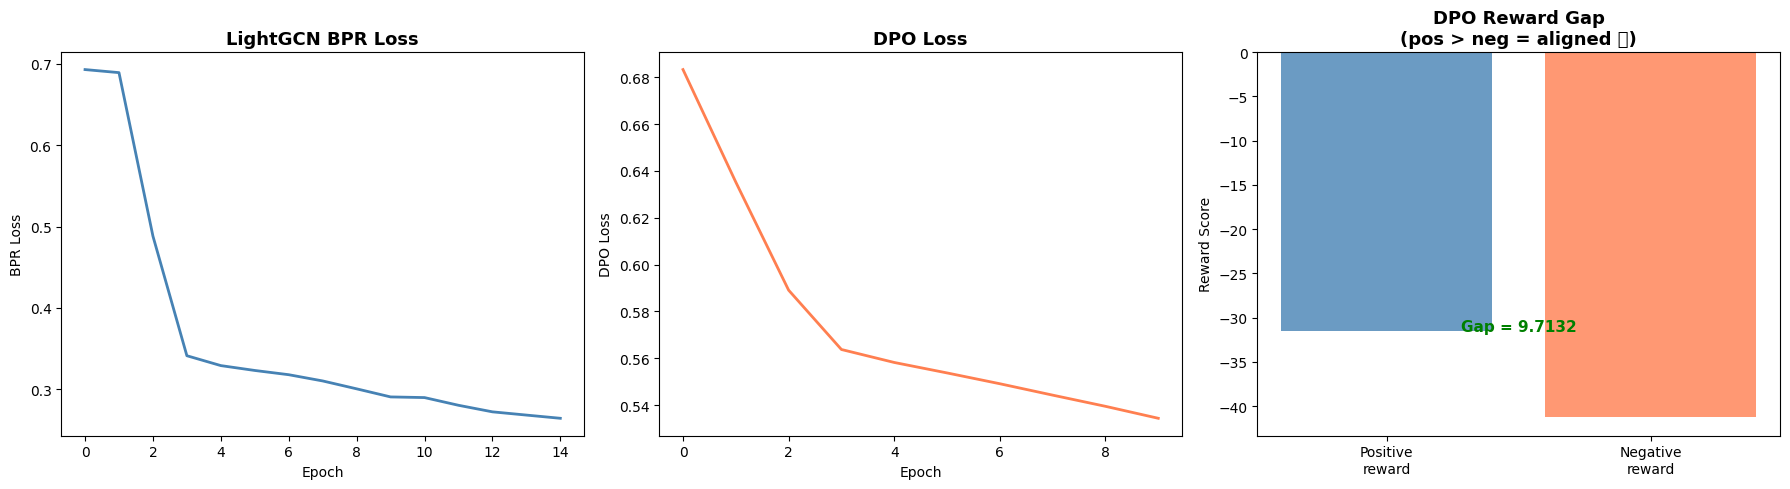

In [11]:
# Training Curves
fig, axes = plt.subplots(1, 3,
                          figsize=(18, 5))

# LightGCN
axes[0].plot(losses, color='steelblue',
             linewidth=2)
axes[0].set_title(
    'LightGCN BPR Loss',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BPR Loss')

# DPO
axes[1].plot(dpo_losses, color='coral',
             linewidth=2)
axes[1].set_title(
    'DPO Loss',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('DPO Loss')

# Reward gap
axes[2].bar(
    ['Positive\nreward',
     'Negative\nreward'],
    [metrics['pos_reward'],
     metrics['neg_reward']],
    color=['steelblue', 'coral'],
    alpha=0.8)
axes[2].set_title(
    'DPO Reward Gap\n(pos > neg = aligned ✅)',
    fontsize=13, fontweight='bold')
axes[2].set_ylabel('Reward Score')

# Add gap annotation
gap = metrics['pos_reward'] - \
      metrics['neg_reward']
axes[2].annotate(
    f'Gap = {gap:.4f}',
    xy=(0.5, max(metrics['pos_reward'],
                 metrics['neg_reward'])),
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='green' if gap > 0 else 'red')

plt.tight_layout()
plt.savefig(
    PROC + 'plots/14_lightgcn_dpo.png',
    bbox_inches='tight')
plt.show()

In [13]:
# Save 
day18_results = {
    "lightgcn": {
        "model":      "LightGCN",
        "paper":      "He et al. 2020",
        "embed_dim":  64,
        "n_layers":   3,
        "best_loss":  round(best_loss, 4),
        "innovation": "graph_multi_hop_propagation",
    },
    "dpo": {
        "model":       "DPO_Aligner",
        "paper":       "Netflix Dec 2025",
        "beta":        0.1,
        "best_loss":   round(best_dpo, 4),
        "reward_gap":  round(avg_gap, 4),
        "aligned":     avg_gap > 0,
        "innovation":  "preference_alignment",
        "pos_pairs":   len(pos_ratings),
        "neg_pairs":   len(neg_ratings),
    },
    "lightgbm_ltr": {
        "model":      "LightGBM_LambdaRank",
        "objective":  "lambdarank",
        "n_trees":    lgbm_model.num_trees(),
        "innovation": "gradient_boosted_ltr",
        "note":       "Spotify production baseline",
    },
}

with open(PROC + 'day18_results.json',
          'w') as f:
    json.dump(day18_results, f, indent=2)

print("✅ All results saved")
print(json.dumps(day18_results, indent=2))

✅ All results saved
{
  "lightgcn": {
    "model": "LightGCN",
    "paper": "He et al. 2020",
    "embed_dim": 64,
    "n_layers": 3,
    "best_loss": 0.2642,
    "innovation": "graph_multi_hop_propagation"
  },
  "dpo": {
    "model": "DPO_Aligner",
    "paper": "Netflix Dec 2025",
    "beta": 0.1,
    "best_loss": 0.5343,
    "reward_gap": 7.1165,
    "aligned": true,
    "innovation": "preference_alignment",
    "pos_pairs": 41576,
    "neg_pairs": 10558
  },
  "lightgbm_ltr": {
    "model": "LightGBM_LambdaRank",
    "objective": "lambdarank",
    "n_trees": 50,
    "innovation": "gradient_boosted_ltr",
    "note": "Spotify production baseline"
  }
}
